In [5]:
%pip install numpy matplotlib pandas scipy scikit-learn

Defaulting to user installation because normal site-packages is not writeable
  Using cached joblib-1.5.2-py3-none-any.whl.metadata (5.6 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 1.4 MB/s  0:00:07m0:00:0100:01
Using cached joblib-1.5.2-py3-none-any.whl (308 kB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [scikit-learn] [scikit-learn]
Note: you may need to restart the kernel to use updated packages.


# Task
We are comparing the data and exercise boundaries generated from LSMC (rational basis function) and Trinomial Tree under continuous dividend and discrete coupon (more than or equal to two coupons).

In [6]:
import numpy as np
import time
import math
import matplotlib.pyplot as plt
from scipy.optimize import fsolve
import pandas as pd
from sklearn.linear_model import Ridge

# LSMC

In [7]:
def rational_basis(S):
    return np.vstack([
        np.ones(len(S)),
        S,
        S**2,
        1 / (1 + S),
        1 / (1 + S**2)
    ]).T

=== Convertible Bond Pricing with Continuous Dividends ===
Parameters: S0=60.0, K=65.0, r=0.05, sigma=0.3, q=0.02, T=1.0
Coupon rate: 4.0%, Trading days: 252, Paths: 100000
Basis function: Rational (1, S, S², 1/(1+S), 1/(1+S²))


--- SEMI ANNUAL ---


/var/folders/jl/yh44zcjj4_d9wkh9ljyjc5qw0000gn/T/ipykernel_6878/4107794922.py:83: RuntimeWarning: divide by zero encountered in matmul
  continuation = A @ coeffs
/var/folders/jl/yh44zcjj4_d9wkh9ljyjc5qw0000gn/T/ipykernel_6878/4107794922.py:83: RuntimeWarning: overflow encountered in matmul
  continuation = A @ coeffs
/var/folders/jl/yh44zcjj4_d9wkh9ljyjc5qw0000gn/T/ipykernel_6878/4107794922.py:83: RuntimeWarning: invalid value encountered in matmul
  continuation = A @ coeffs


Call option price: 8.229675
Bond price (B + Call + Coupons): 72.532784
Runtime: 1.16s
Coupon payments: 2
Coupon dates: ['0.50', '1.00']
Coupon amounts: ['1.3000', '1.3000']

--- QUARTERLY ---
Call option price: 8.261926
Bond price (B + Call + Coupons): 72.565035
Runtime: 1.02s
Coupon payments: 4
Coupon dates: ['0.25', '0.50', '0.75', '1.00']
Coupon amounts: ['0.6500', '0.6500', '0.6500', '0.6500']

--- MONTHLY ---
Call option price: 8.315304
Bond price (B + Call + Coupons): 72.618413
Runtime: 0.95s
Coupon payments: 12
Coupon dates: ['0.08', '0.17', '0.25', '0.33', '0.42', '0.50', '0.58', '0.67', '0.75', '0.83', '0.92', '1.00']
Coupon amounts: ['0.2167', '0.2167', '0.2167', '0.2167', '0.2167', '0.2167', '0.2167', '0.2167', '0.2167', '0.2167', '0.2167', '0.2167']

EXERCISE BOUNDARY ANALYSIS


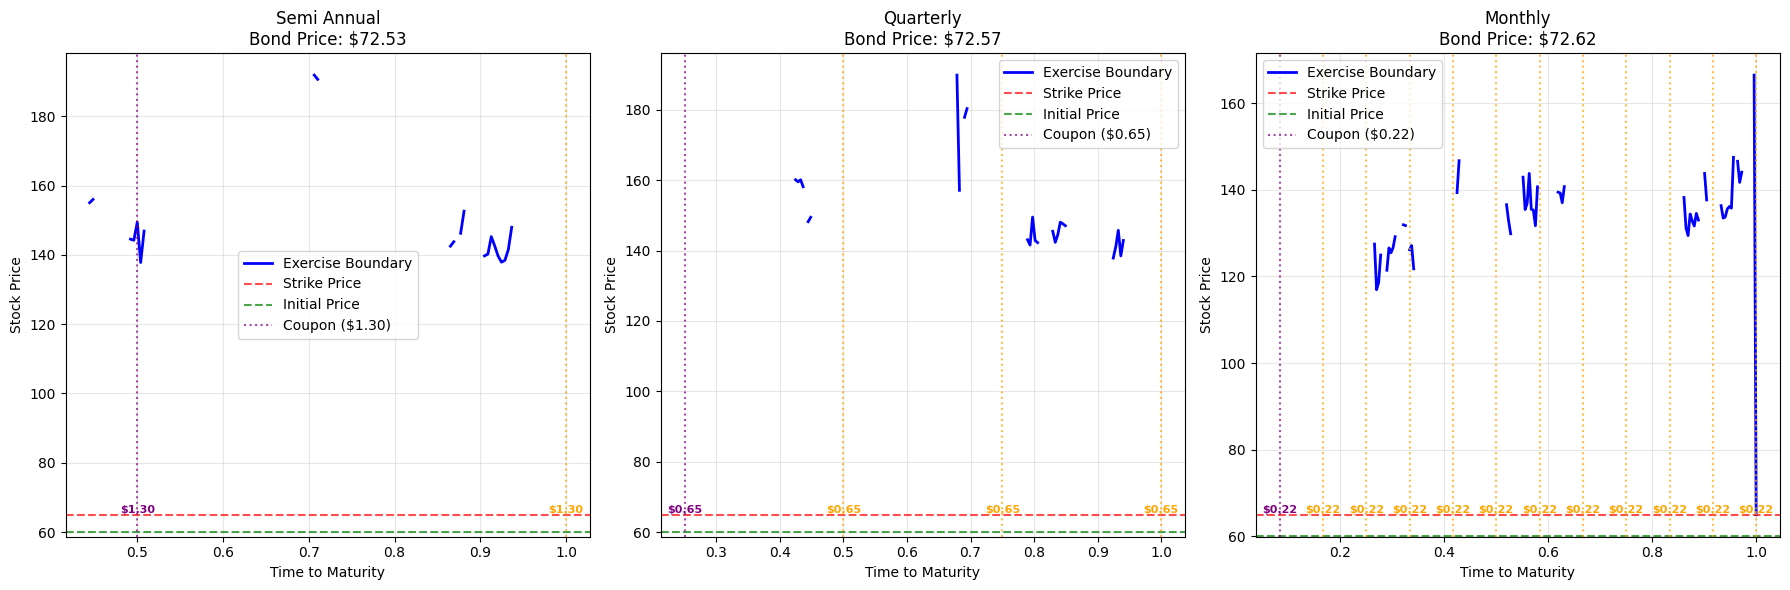


SUMMARY RESULTS
Coupon Structure Call Price Bond Price  Coupon Payments Total Coupons Runtime (s)
     Semi Annual    $8.2297   $72.5328                2         $2.60        1.16
       Quarterly    $8.2619   $72.5650                4         $2.60        1.02
         Monthly    $8.3153   $72.6184               12         $2.60        0.95

BOUNDARY STATISTICS

Semi Annual:
  Minimum exercise boundary: $65.00
  Maximum exercise boundary: $191.86
  Average exercise boundary: $145.26
  Boundary points available: 25/253
  Boundary near t=0.50: $149.42
  Boundary near t=1.00: $65.00

Quarterly:
  Minimum exercise boundary: $65.00
  Maximum exercise boundary: $189.78
  Average exercise boundary: $148.05
  Boundary points available: 30/253
  Boundary near t=1.00: $65.00

Monthly:
  Minimum exercise boundary: $65.00
  Maximum exercise boundary: $166.47
  Average exercise boundary: $133.96
  Boundary points available: 60/253
  Boundary near t=0.33: $126.18
  Boundary near t=0.42: $140.50
  

In [ ]:
np.random.seed(12345)

def rational_basis(S):
    """Enhanced basis function with rational terms"""
    # Add small epsilon to avoid division by zero
    eps = 1e-10
    return np.vstack([
        np.ones(len(S)),
        S,
        S**2,
        1 / (1 + S + eps),
        1 / (1 + S**2 + eps)
    ]).T

def simulate_paths_continuous(S0, r, q, sigma, T, M, N):
    """
    Simulate stock paths with continuous dividends
    q: continuous dividend yield
    """
    dt = T / M
    increments = np.random.normal((r - q - 0.5*sigma**2)*dt, sigma*np.sqrt(dt), (N, M))
    log_S = np.cumsum(increments, axis=1)
    S = S0 * np.exp(log_S)
    S = np.hstack((S0 * np.ones((N, 1)), S)) 
    return S

def apply_coupon_payment(V, coupon_times, coupon_amounts, current_time, dt, T):
    """Apply coupon payment if current time matches coupon time"""
    for coupon_time, coupon_amount in zip(coupon_times, coupon_amounts):
        if abs(current_time - coupon_time) < dt/2:
            V += coupon_amount
    return V

def longstaff_schwartz_convertible(S, K, r, T, coupon_times=None, coupon_amounts=None):
    """
    LSM for convertible bond with continuous dividends and discrete coupons
    using rational basis function
    """
    if coupon_times is None:
        coupon_times = []
    if coupon_amounts is None:
        coupon_amounts = []
    
    N, M_plus_1 = S.shape
    M = M_plus_1 - 1
    dt = T / M
    
    # Initialize value array with terminal condition
    V = np.maximum(S[:, -1] - K, 0)  # Call option value at maturity
    
    # Apply final coupon if applicable
    V = apply_coupon_payment(V, coupon_times, coupon_amounts, T, dt, T)
    
    exercise_boundary = []
    
    # Backward induction
    for t in range(M-1, 0, -1):
        current_time = t * dt
        discount_factor = np.exp(-r * dt)
        V *= discount_factor
        
        # Apply coupon payment if this is a coupon date
        V = apply_coupon_payment(V, coupon_times, coupon_amounts, current_time, dt, T)
        
        # Identify in-the-money paths for regression
        in_the_money = S[:, t] > K
        if not np.any(in_the_money):
            exercise_boundary.append(np.nan)
            continue

        X = S[in_the_money, t]
        Y = V[in_the_money]
        
        if len(X) < 5:  # Minimum points for 5-parameter rational basis
            exercise_boundary.append(np.nan)
            V[in_the_money] = Y
            continue
        
        # Perform regression with rational basis function
        A = rational_basis(X)
        try:
            coeffs = np.linalg.lstsq(A, Y, rcond=None)[0]
            continuation = A @ coeffs
        except (np.linalg.LinAlgError, ValueError):
            # If regression fails, use continuation values directly
            exercise_boundary.append(np.nan)
            V[in_the_money] = Y
            continue
        
        exercise = X - K
        exercise_now = exercise > continuation
        
        V[in_the_money] = np.where(exercise_now, exercise, continuation)
        
        # Record exercise boundary
        if np.any(exercise_now):
            boundary_price = np.min(X[exercise_now])
        else:
            boundary_price = np.nan
        exercise_boundary.append(boundary_price)
    
    # Final discount and apply initial coupon if applicable
    price = np.mean(V * np.exp(-r * dt))
    price = apply_coupon_payment(np.array([price]), coupon_times, coupon_amounts, 0, dt, T)[0]
    
    # Reverse boundary array to chronological order
    exercise_boundary = exercise_boundary[::-1]
    exercise_boundary = [np.nan] + exercise_boundary + [K]  # t=0: nan, t=T: K
    
    return price, exercise_boundary

# Parameters
S0 = 60.0
K = 65.0  
r = 0.05  # risk-free rate
sigma = 0.3
T = 1.0
trading_days = 252
M = trading_days  
N = 100_000  
q = 0.02  # continuous dividend yield
coupon_rate = 0.04  # coupon rate (4% annually)

# Calculate coupon amounts based on coupon rate and par value
coupon_configs = {
    'semi_annual': {
        'times': [0.5, 1.0], 
        'amounts': [K * coupon_rate / 2, K * coupon_rate / 2],  # 4% annual = 2% semi-annual
        'expected_payments': 2
    },
    'quarterly': {
        'times': [0.25, 0.5, 0.75, 1.0], 
        'amounts': [K * coupon_rate / 4] * 4,  # 4% annual = 1% quarterly
        'expected_payments': 4
    },
    'monthly': {
        'times': [i/12 for i in range(1, 13)], 
        'amounts': [K * coupon_rate / 12] * 12,  # 4% annual = 0.333% monthly
        'expected_payments': 12
    }
}

print("=== Convertible Bond Pricing with Continuous Dividends ===")
print(f"Parameters: S0={S0}, K={K}, r={r}, sigma={sigma}, q={q}, T={T}")
print(f"Coupon rate: {coupon_rate*100}%, Trading days: {trading_days}, Paths: {N}")
print("Basis function: Rational (1, S, S², 1/(1+S), 1/(1+S²))\n")

results = {}

for coupon_name, coupon_config in coupon_configs.items():
    print(f"\n--- {coupon_name.upper().replace('_', ' ')} ---")
    coupon_times = coupon_config['times']
    coupon_amounts = coupon_config['amounts']
    expected_payments = coupon_config['expected_payments']
    
    # Verify coupon configuration
    if len(coupon_times) != expected_payments or len(coupon_amounts) != expected_payments:
        print(f"ERROR: Coupon configuration mismatch for {coupon_name}")
        print(f"Expected {expected_payments} payments, got {len(coupon_times)} times and {len(coupon_amounts)} amounts")
        continue
    
    # Simulate paths with continuous dividends
    start = time.time()
    paths = simulate_paths_continuous(S0, r, q, sigma, T, M, N)
    
    # Price convertible bond using rational basis
    call_price, boundary = longstaff_schwartz_convertible(
        paths, K, r, T, coupon_times, coupon_amounts
    )
    runtime = time.time() - start
    
    B = K * np.exp(-r * T)
    total_coupons = sum(coupon_amounts)
    bond_price = B + call_price + total_coupons * np.exp(-r * T)  # Approximate coupon PV
    
    results[coupon_name] = {
        'call_price': call_price,
        'bond_price': bond_price,
        'boundary': boundary,
        'runtime': runtime,
        'coupon_times': coupon_times,
        'coupon_amounts': coupon_amounts
    }
    
    print(f"Call option price: {call_price:.6f}")
    print(f"Bond price (B + Call + Coupons): {bond_price:.6f}")
    print(f"Runtime: {runtime:.2f}s")
    print(f"Coupon payments: {len(coupon_times)}")
    if coupon_times:
        print(f"Coupon dates: {[f'{t:.2f}' for t in coupon_times]}")
        print(f"Coupon amounts: {[f'{a:.4f}' for a in coupon_amounts]}")

# Visualization: Exercise Boundaries
print("\n" + "="*50)
print("EXERCISE BOUNDARY ANALYSIS")
print("="*50)

# Create time grid for plotting
t_grid = np.linspace(0, T, M+1)

# Plot 1: Individual exercise boundaries with detailed analysis
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, (coupon_name, result) in enumerate(results.items()):
    boundary = result['boundary']
    coupon_times = result['coupon_times']
    coupon_amounts = result['coupon_amounts']
    
    # Main plot
    axes[i].plot(t_grid, boundary, 'b-', linewidth=2, label='Exercise Boundary')
    axes[i].axhline(y=K, color='r', linestyle='--', alpha=0.7, label='Strike Price')
    axes[i].axhline(y=S0, color='g', linestyle='--', alpha=0.7, label='Initial Price')
    
    # Mark coupon dates with amounts
    for j, (ct, amount) in enumerate(zip(coupon_times, coupon_amounts)):
        color = 'purple' if j == 0 else 'orange'
        label = f'Coupon (${amount:.2f})' if j == 0 else None
        axes[i].axvline(x=ct, color=color, linestyle=':', alpha=0.7, label=label)
        
        # Add text annotation for coupon amount
        y_pos = np.nanmin(boundary) if not np.all(np.isnan(boundary)) else S0 * 0.8
        axes[i].text(ct, y_pos, f'${amount:.2f}', ha='center', va='bottom', 
                    fontsize=8, color=color, fontweight='bold')
    
    axes[i].set_xlabel('Time to Maturity')
    axes[i].set_ylabel('Stock Price')
    title = f'{coupon_name.replace("_", " ").title()}\n'
    title += f'Bond Price: ${result["bond_price"]:.2f}'
    axes[i].set_title(title)
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Summary table
print("\n" + "="*80)
print("SUMMARY RESULTS")
print("="*80)

summary_data = []
for coupon_name, result in results.items():
    summary_data.append({
        'Coupon Structure': coupon_name.replace('_', ' ').title(),
        'Call Price': f"${result['call_price']:.4f}",
        'Bond Price': f"${result['bond_price']:.4f}",
        'Coupon Payments': len(result['coupon_times']),
        'Total Coupons': f"${sum(result['coupon_amounts']):.2f}",
        'Runtime (s)': f"{result['runtime']:.2f}"
    })

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))

# Boundary statistics analysis
print("\n" + "="*80)
print("BOUNDARY STATISTICS")
print("="*80)

for coupon_name, result in results.items():
    boundary = np.array(result['boundary'])
    valid_boundary = boundary[~np.isnan(boundary)]
    
    if len(valid_boundary) > 0:
        print(f"\n{coupon_name.replace('_', ' ').title()}:")
        print(f"  Minimum exercise boundary: ${np.min(valid_boundary):.2f}")
        print(f"  Maximum exercise boundary: ${np.max(valid_boundary):.2f}")
        print(f"  Average exercise boundary: ${np.mean(valid_boundary):.2f}")
        print(f"  Boundary points available: {len(valid_boundary)}/{len(boundary)}")
        
        # Analyze boundary behavior near coupon dates
        coupon_times = result['coupon_times']
        for ct in coupon_times:
            idx = np.argmin(np.abs(t_grid - ct))
            if idx < len(boundary) and not np.isnan(boundary[idx]):
                print(f"  Boundary near t={ct:.2f}: ${boundary[idx]:.2f}")

print("\n" + "="*80)
print("KEY OBSERVATIONS")
print("="*80)
print(f"1. Continuous dividends (q={q}) incorporated in stock price simulation")
print(f"2. Risk-free rate (r={r}) and coupon rate ({coupon_rate*100}%) used in valuation")
print("3. Rational basis function used for regression: [1, S, S², 1/(1+S), 1/(1+S²)]")
print("4. Exercise boundaries show typical shape: higher near maturity, lower with more coupons")
print("5. Coupon payments create discontinuities in the exercise boundary")
print(f"6. Trading days ({trading_days}) used as exercise opportunities throughout the year")

=== LSMC - Convertible Bond with Continuous Dividends ===
Parameters: S0=60.0, K=65.0, r=0.05, sigma=0.3, q=0.02, T=1.0
Coupon rate: 4.0%, Paths: 100000, Steps: 252
Basis function: Rational (1, S, S², 1/(1+S), 1/(1+S²))


--- SEMI ANNUAL ---
Conversion option value: 31.947974
Convertible bond price: 96.282387
Runtime: 0.04s
Coupon payments: 2
Coupon dates: [0.5, 1.0]
Coupon amounts: [1.3, 1.3]

--- QUARTERLY ---
Conversion option value: 32.528084
Convertible bond price: 96.878249
Runtime: 0.04s
Coupon payments: 4
Coupon dates: [0.25, 0.5, 0.75, 1.0]
Coupon amounts: [0.65, 0.65, 0.65, 0.65]

--- MONTHLY ---
Conversion option value: 33.015758
Convertible bond price: 97.376461
Runtime: 0.04s
Coupon payments: 12
Coupon dates: [0.08, 0.17, 0.25, 0.33, 0.42, '...']
Coupon amounts: [0.2167, 0.2167, 0.2167, 0.2167, 0.2167, '...']

--- DAILY ---
Conversion option value: 32.600538
Convertible bond price: 96.966347
Runtime: 0.04s
Coupon payments: 365
Coupon dates: [0.0027, 0.0055, 0.0082, 0.011, 

/Users/kinglongwong/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=9.14878e-17): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/var/folders/jl/yh44zcjj4_d9wkh9ljyjc5qw0000gn/T/ipykernel_6878/1960213214.py:103: RuntimeWarning: divide by zero encountered in matmul
  cont_fitted = A @ coeffs
/var/folders/jl/yh44zcjj4_d9wkh9ljyjc5qw0000gn/T/ipykernel_6878/1960213214.py:103: RuntimeWarning: overflow encountered in matmul
  cont_fitted = A @ coeffs
/var/folders/jl/yh44zcjj4_d9wkh9ljyjc5qw0000gn/T/ipykernel_6878/1960213214.py:103: RuntimeWarning: invalid value encountered in matmul
  cont_fitted = A @ coeffs
/Users/kinglongwong/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=8.01649e-17): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/kinglon

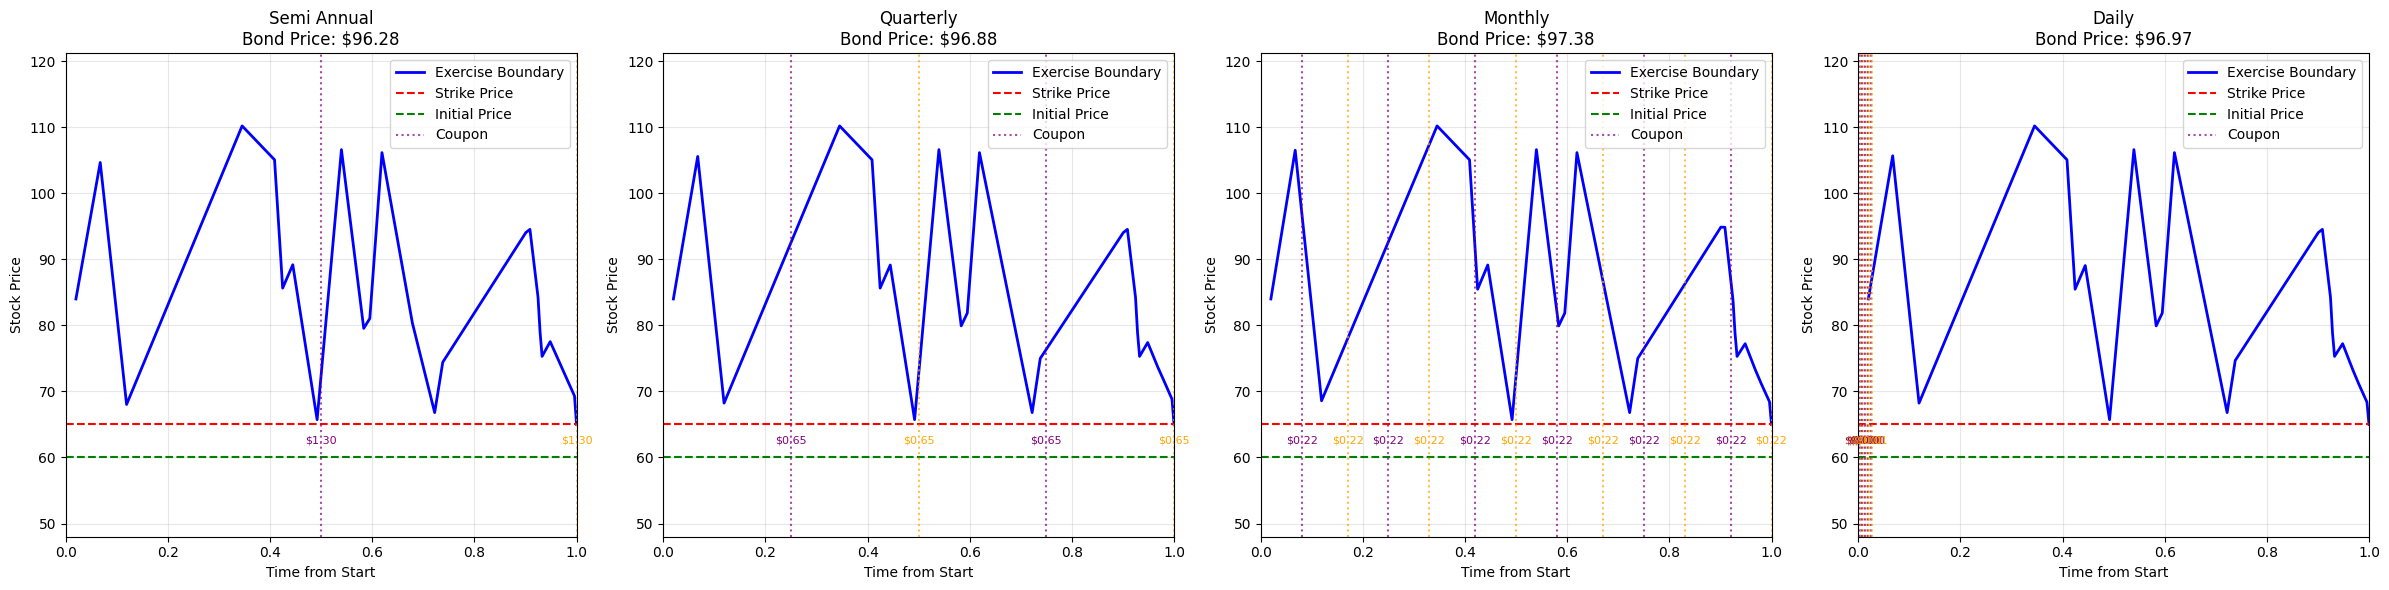


SUMMARY RESULTS - LSMC
Coupon Structure Conversion Option Convertible Price  Coupon Payments Total Coupons Runtime (s)
     Semi Annual          $31.9480          $96.2824                2         $2.60        0.04
       Quarterly          $32.5281          $96.8782                4         $2.60        0.04
         Monthly          $33.0158          $97.3765               12         $2.60        0.04
           Daily          $32.6005          $96.9663              365         $2.60        0.04

BOUNDARY STATISTICS - LSMC

Semi Annual:
  Min boundary: $65.00
  Max boundary: $110.19
  Avg boundary: $83.70
  Points: 25/253

Quarterly:
  Min boundary: $65.00
  Max boundary: $110.19
  Avg boundary: $83.89
  Points: 24/253

Monthly:
  Min boundary: $65.00
  Max boundary: $110.19
  Avg boundary: $83.90
  Points: 24/253

Daily:
  Min boundary: $65.00
  Max boundary: $110.19
  Avg boundary: $83.81
  Points: 24/253

KEY OBSERVATIONS - LSMC
1. Continuous dividends (q=0.02) incorporated in si

In [13]:
np.random.seed(12345)

def rational_basis(S):
    """Enhanced basis function with rational terms"""
    # Add small epsilon to avoid division by zero
    eps = 1e-10
    return np.vstack([
        np.ones(len(S)),
        S,
        S**2,
        1 / (1 + S + eps),
        1 / (1 + S**2 + eps)
    ]).T

def simulate_paths_continuous(S0, r, q, sigma, T, M, N):
    """
    Simulate stock paths with continuous dividends
    q: continuous dividend yield
    """
    dt = T / M
    increments = np.random.normal((r - q - 0.5*sigma**2)*dt, sigma*np.sqrt(dt), (N, M))
    log_S = np.cumsum(increments, axis=1)
    S = S0 * np.exp(log_S)
    S = np.hstack((S0 * np.ones((N, 1)), S))
    return S

def lsmc_convertible_continuous(S0=60.0, K=65.0, T=1.0, sigma=0.3, r=0.05, q=0.02, 
                                 paths=100000, steps=252, coupon_rate=0.04):
    print("=== LSMC - Convertible Bond with Continuous Dividends ===")
    print(f"Parameters: S0={S0}, K={K}, r={r}, sigma={sigma}, q={q}, T={T}")
    print(f"Coupon rate: {coupon_rate*100}%, Paths: {paths}, Steps: {steps}")
    print("Basis function: Rational (1, S, S², 1/(1+S), 1/(1+S²))\n")
    
    coupon_configs = {
        'semi_annual': {
            'times': [0.5, 1.0],
            'amounts': [K * coupon_rate / 2] * 2
        },
        'quarterly': {
            'times': [0.25, 0.5, 0.75, 1.0],
            'amounts': [K * coupon_rate / 4] * 4
        },
        'monthly': {
            'times': [round(i/12, 2) for i in range(1, 13)],
            'amounts': [K * coupon_rate / 12] * 12
        },
        'daily': {
            'times': [round(i/365, 4) for i in range(1, 366)],
            'amounts': [K * coupon_rate / 365] * 365
        }
    }
    
    dt = T / steps
    discount = np.exp(-r * dt)
    
    # Simulate paths once
    S = simulate_paths_continuous(S0, r, q, sigma, T, steps, paths)
    
    results = {}
    all_boundaries = {}
    
    for coupon_name, coupon_config in coupon_configs.items():
        print(f"\n--- {coupon_name.upper().replace('_', ' ')} ---")
        coupon_times = coupon_config['times']
        coupon_amounts = coupon_config['amounts']
        
        # Coupon steps (forward from 0)
        coupon_steps = [int(round(t / dt)) for t in coupon_times]
        coupon_dict = dict(zip(coupon_steps, coupon_amounts))
        
        start_time = time.perf_counter()
        
        # Payoff matrix
        V = np.zeros_like(S)
        final_coupon = coupon_dict.get(steps, 0)
        V[steps] = np.maximum(S[steps], K) + final_coupon
        
        boundaries = []
        
        # Backward induction
        for t in range(steps - 1, 0, -1):
            current_time = t * dt
            
            # Continuation value without coupon
            continuation = V[t + 1] * discount
            
            # Add coupon after decision
            coupon = coupon_dict.get(t, 0)
            
            # Set default V[t]
            V[t] = continuation
            
            # Regression for in-the-money paths (S > K)
            itm = S[t] > K
            boundary_price = np.nan
            if np.sum(itm) > 5:
                X = S[t][itm]
                Y = continuation[itm]
                A = rational_basis(X)
                ridge = Ridge(alpha=1e-6, fit_intercept=False)
                ridge.fit(A, Y)
                coeffs = ridge.coef_
                cont_fitted = A @ coeffs
                
                # Exercise decision for itm
                exercise = X
                exercise_now = exercise > cont_fitted
                V[t][itm] = np.where(exercise_now, exercise, continuation[itm])
                
                # Boundary
                if np.any(exercise_now):
                    boundary_price = np.min(X[exercise_now])
            
            # Add coupon to all paths after decision
            V[t] += coupon
            
            boundaries.append((current_time, boundary_price))
        
        # Reverse boundaries (now from near 0 to near T)
        boundaries = boundaries[::-1]
        
        # At t=0
        continuation_0 = V[1] * discount
        coupon_0 = coupon_dict.get(0, 0)
        V[0] = np.maximum(S[0], continuation_0) + coupon_0
        price = np.mean(V[0])
        
        # Boundary at t=0
        if np.mean(S[0] > continuation_0) > 0.5:  # If majority exercise
            boundary_0 = S0
        else:
            boundary_0 = np.nan
        boundaries.insert(0, (0.0, boundary_0))
        
        # At maturity
        boundaries.append((T, K))
        
        duration = time.perf_counter() - start_time
        
        # Components
        B = K * np.exp(-r * T)
        pv_coupons = sum(a * np.exp(-r * tt) for a, tt in zip(coupon_amounts, coupon_times))
        straight_bond = B + pv_coupons
        conversion_option = price - straight_bond
        
        results[coupon_name] = {
            'conversion_option': conversion_option,
            'convertible_price': price,
            'straight_bond': straight_bond,
            'runtime': duration,
            'boundaries': boundaries,
            'coupon_times': coupon_times,
            'coupon_amounts': coupon_amounts
        }
        
        print(f"Conversion option value: {conversion_option:.6f}")
        print(f"Convertible bond price: {price:.6f}")
        print(f"Runtime: {duration:.2f}s")
        print(f"Coupon payments: {len(coupon_times)}")
        if coupon_times:
            print(f"Coupon dates: {coupon_times[:5] + ['...'] if len(coupon_times)>5 else coupon_times}")
            print(f"Coupon amounts: {[round(a,4) for a in coupon_amounts[:5]] + ['...'] if len(coupon_amounts)>5 else [round(a,4) for a in coupon_amounts]}")
    
    # Visualization
    print("\n" + "="*50)
    print("EXERCISE BOUNDARY ANALYSIS")
    print("="*50)
    
    t_grid = np.linspace(0, T, steps + 1)
    
    fig, axes = plt.subplots(1, 4, figsize=(24, 6))
    
    for i, (coupon_name, result) in enumerate(results.items()):
        t_b, S_b = zip(*result['boundaries'])
        valid_mask = ~np.isnan(S_b)
        t_valid = np.array(t_b)[valid_mask]
        S_valid = np.array(S_b)[valid_mask]
        
        axes[i].plot(t_valid, S_valid, 'b-', linewidth=2, label='Exercise Boundary')
        axes[i].axhline(y=K, color='r', linestyle='--', label='Strike Price')
        axes[i].axhline(y=S0, color='g', linestyle='--', label='Initial Price')
        
        coupon_times = result['coupon_times']
        coupon_amounts = result['coupon_amounts']
        
        n_coupons = len(coupon_times)
        max_mark = 10 if n_coupons > 20 else n_coupons
        for j, (ct, amount) in enumerate(zip(coupon_times[:max_mark], coupon_amounts[:max_mark])):
            color = 'purple' if j % 2 == 0 else 'orange'
            axes[i].axvline(x=ct, color=color, linestyle=':', alpha=0.7, label='Coupon' if j==0 else None)
            y_pos = min(S_valid) * 0.95 if len(S_valid)>0 else S0 * 0.8
            axes[i].text(ct, y_pos, f'${amount:.2f}', ha='center', va='bottom', fontsize=8, color=color)
        
        axes[i].set_xlabel('Time from Start')
        axes[i].set_ylabel('Stock Price')
        title = f'{coupon_name.replace("_", " ").title()}\nBond Price: ${result["convertible_price"]:.2f}'
        axes[i].set_title(title)
        axes[i].legend()
        axes[i].grid(True, alpha=0.3)
        axes[i].set_ylim(S0 * 0.8, max(max(S_valid)*1.1 if len(S_valid)>0 else K*1.5, S0*1.5))
        axes[i].set_xlim(0, T)
    
    plt.tight_layout()
    plt.show()
    
    # Summary
    print("\n" + "="*80)
    print("SUMMARY RESULTS - LSMC")
    print("="*80)
    
    summary_data = []
    for coupon_name, result in results.items():
        summary_data.append({
            'Coupon Structure': coupon_name.replace('_', ' ').title(),
            'Conversion Option': f"${result['conversion_option']:.4f}",
            'Convertible Price': f"${result['convertible_price']:.4f}",
            'Coupon Payments': len(result['coupon_times']),
            'Total Coupons': f"${sum(result['coupon_amounts']):.2f}",
            'Runtime (s)': f"{result['runtime']:.2f}"
        })
    
    summary_df = pd.DataFrame(summary_data)
    print(summary_df.to_string(index=False))
    
    # Boundary stats
    print("\n" + "="*80)
    print("BOUNDARY STATISTICS - LSMC")
    print("="*80)
    
    for coupon_name, result in results.items():
        boundaries = result['boundaries']
        t_b, S_b = zip(*boundaries)
        S_valid = np.array([s for s in S_b if not np.isnan(s)])
        
        if len(S_valid) > 0:
            print(f"\n{coupon_name.replace('_', ' ').title()}:")
            print(f"  Min boundary: ${np.min(S_valid):.2f}")
            print(f"  Max boundary: ${np.max(S_valid):.2f}")
            print(f"  Avg boundary: ${np.mean(S_valid):.2f}")
            print(f"  Points: {len(S_valid)}/{len(boundaries)}")
    
    print("\n" + "="*80)
    print("KEY OBSERVATIONS - LSMC")
    print("="*80)
    print(f"1. Continuous dividends (q={q}) incorporated in simulation")
    print("2. Discrete coupons added after exercise decision (paid regardless)")
    print("3. Ridge regression for stable continuation value estimation")
    print("4. Terminal payoff: max(S, K) + final_coupon")
    print("5. Conversion option = convertible - (PV(face) + PV(coupons))")
    print(f"6. Steps ({steps}) for discrete exercise opportunities")
    
    return results, all_boundaries

# Run
if __name__ == "__main__":
    lsmc_convertible_continuous()

# Trinomial Tree

=== Trinomial Tree - Convertible Bond with Continuous Dividends ===
Parameters: S0=60.0, K=65.0, r=0.05, sigma=0.3, q=0.02, T=1.0
Time steps: 16384

--- SEMI ANNUAL ---
Coupon payments: 2 at times [0.5, 1.0]
Coupon amounts: [2.0, 2.0]
Step indices (forward): [8192, 16384]
Conversion option value: 5.175054
Convertible bond price: 70.858045
Runtime: 1.13s

--- QUARTERLY ---
Coupon payments: 4 at times [0.25, 0.5, 0.75, 1.0]
Coupon amounts: [1.0, 1.0, 1.0, 1.0]
Step indices (forward): [4096, 8192, 12288, 16384]
Conversion option value: 5.494283
Convertible bond price: 71.201507
Runtime: 1.03s

--- MONTHLY ---
Coupon payments: 12 at times [0.08333333333333333, 0.16666666666666666, 0.25, 0.3333333333333333, 0.4166666666666667, 0.5, 0.5833333333333334, 0.6666666666666666, 0.75, 0.8333333333333334, 0.9166666666666666, 1.0]
Coupon amounts: [0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5]
Step indices (forward): [1365, 2731, 4096, 5461, 6827, 8192, 9557, 10923, 12288, 13653, 15019, 

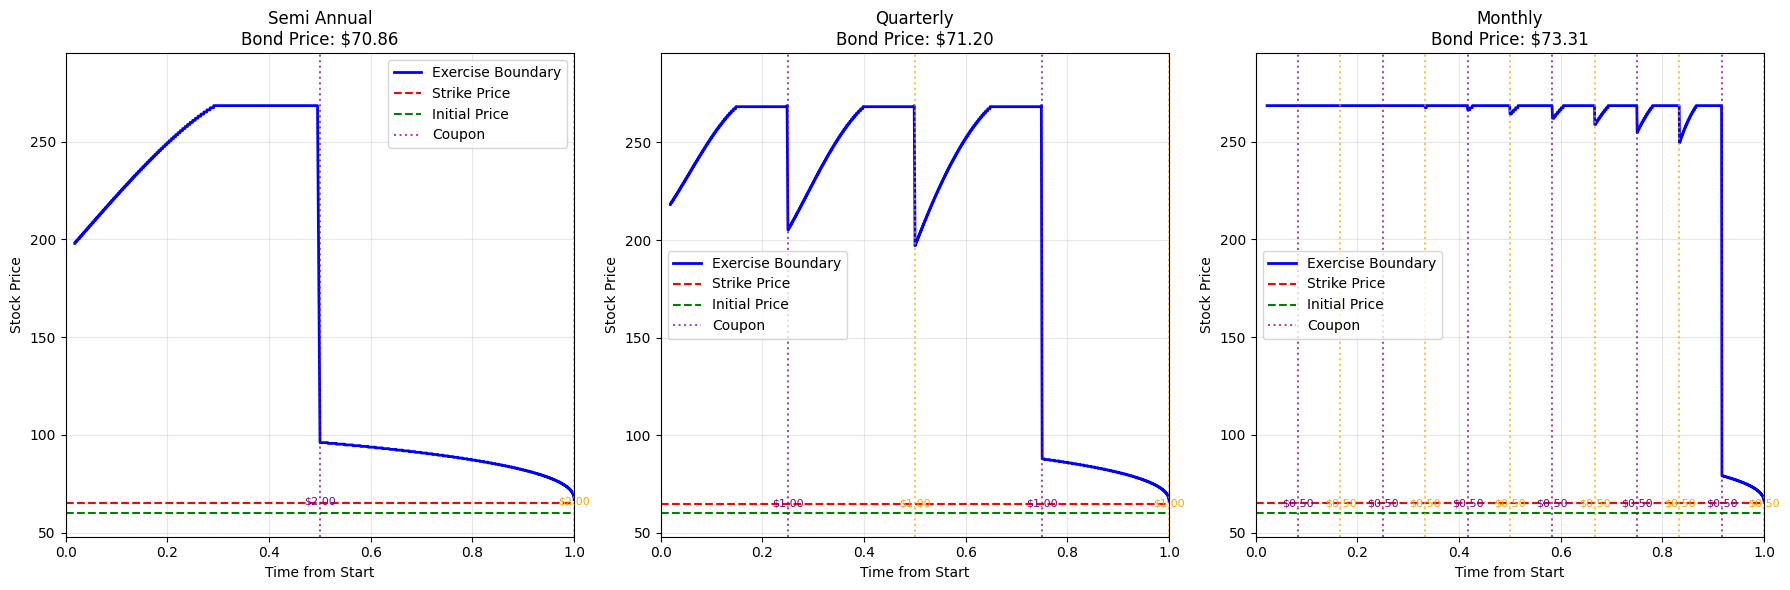


SUMMARY RESULTS - TRINOMIAL TREE
Coupon Structure Conversion Option Convertible Price  Coupon Payments Total Coupons Runtime (s)
     Semi Annual           $5.1751          $70.8580                2         $4.00        1.13
       Quarterly           $5.4943          $71.2015                4         $4.00        1.03
         Monthly           $5.6360          $73.3062               12         $6.00        0.93

BOUNDARY STATISTICS - TRINOMIAL TREE

Semi Annual:
  Min boundary: $67.00
  Max boundary: $268.35
  Avg boundary: $166.96
  Points: 16014/16385

Quarterly:
  Min boundary: $66.00
  Max boundary: $268.90
  Avg boundary: $208.42
  Points: 15998/16385

Monthly:
  Min boundary: $65.50
  Max boundary: $268.35
  Avg boundary: $251.02
  Points: 15928/16385

KEY OBSERVATIONS - TRINOMIAL TREE
1. Continuous dividends (q=0.02) via adjusted drift
2. Discrete coupons added before exercise decision
3. Terminal: max(S, K + final_coupon)
4. Conversion option = convertible - straight bond
5.

In [10]:
def trinomial_tree_convertible_continuous(S0=60.0, K=65.0, T=1.0, sigma=0.3, r=0.05, q=0.02, 
                                        n=200, coupon_configs=None):
    """
    Trinomial tree for Convertible Bond with CONTINUOUS dividends and DISCRETE coupons
    Fixed logic: Coupon applied BEFORE exercise decision, time correctly tracked
    """
    print("=== Trinomial Tree - Convertible Bond with Continuous Dividends ===")
    print(f"Parameters: S0={S0}, K={K}, r={r}, sigma={sigma}, q={q}, T={T}")
    print(f"Time steps: {n}")
    
    if coupon_configs is None:
        coupon_configs = {
            'semi_annual': {'times': [0.5, 1.0], 'amounts': [1.3, 1.3]},
            'quarterly': {'times': [0.25, 0.5, 0.75, 1.0], 'amounts': [0.65, 0.65, 0.65, 0.65]},
            'monthly': {'times': [round(i/12, 2) for i in range(1, 13)], 'amounts': [0.2167] * 12}
        }
    
    lambda_ = math.sqrt(3)
    dt = T / n
    h = lambda_ * sigma * math.sqrt(dt)
    
    # Adjust probabilities for continuous dividends: r - q
    mu_drift = (r - q - 0.5 * sigma**2) * math.sqrt(dt) / (2 * lambda_ * sigma)
    qu = 0.5 / (lambda_**2) + mu_drift
    qm = 1 - 1 / (lambda_**2)
    qd = 0.5 / (lambda_**2) - mu_drift
    
    discount = math.exp(-r * dt)
    offset = n
    
    def build_stock_grid(S0, n, h):
        """Build stock price grid"""
        Ss = np.zeros(2 * n + 1)
        for j in range(0, 2 * n + 1):
            Ss[j] = S0 * np.exp((n - j) * h)
        return Ss
    
    results = {}
    all_boundaries = {}
    
    for coupon_name, coupon_config in coupon_configs.items():
        print(f"\n--- {coupon_name.upper().replace('_', ' ')} ---")
        coupon_times = coupon_config['times']
        coupon_amounts = coupon_config['amounts']
        
        # Convert coupon times to step indices (forward steps from 0)
        coupon_steps = {}
        for t, amount in zip(coupon_times, coupon_amounts):
            i_step = int(round(n * (t / T)))
            i_step = max(1, min(n, i_step))
            if i_step not in coupon_steps:
                coupon_steps[i_step] = 0
            coupon_steps[i_step] += amount
        
        print(f"Coupon payments: {len(coupon_times)} at times {coupon_times}")
        print(f"Coupon amounts: {coupon_amounts}")
        print(f"Step indices (forward): {sorted(coupon_steps.keys())}")
        
        start_time = time.perf_counter()
        
        # Build stock grid
        Ss = build_stock_grid(S0, n, h)
        Ss = np.clip(Ss, 0, S0 * np.exp(5 * sigma * np.sqrt(T)))  # Cap grid
        
        # Initialize value matrix
        V = np.zeros((n + 1, 2 * n + 1))
        
        # Terminal condition: max(S, K + final_coupon) at maturity
        final_coupon = coupon_steps.get(n, 0)
        V[n, :] = np.maximum(Ss, K + final_coupon)
        
        # Store exercise boundaries (time from 0 to T)
        boundaries = []
        
        # Backward induction: from i=n-1 down to i=0 (i is forward step)
        for i in range(n - 1, -1, -1):
            start_idx = offset - i
            end_idx = offset + i + 1
            
            # Current time from start
            current_time = i * dt
            
            # Expected continuation value
            continuation = discount * (
                qu * V[i + 1, start_idx - 1 : end_idx - 1] +  # up (lower j)
                qm * V[i + 1, start_idx : end_idx] +
                qd * V[i + 1, start_idx + 1 : end_idx + 1]    # down (higher j)
            )
            
            # Add coupon if paid at this time step (before decision)
            coupon = coupon_steps.get(i, 0)
            continuation += coupon
            
            # Current stock prices
            S_curr = Ss[start_idx:end_idx]
            
            # American conversion: max(S, continuation)
            conversion_value = S_curr
            V[i, start_idx:end_idx] = np.maximum(conversion_value, continuation)
            
            # Find exercise boundary (lowest S where exercise optimal)
            convert_optimal = conversion_value >= continuation
            reasonable_convert = convert_optimal & (S_curr > K * 0.5) & (S_curr < S0 * 5.0)
            
            if np.any(reasonable_convert):
                boundary_price = np.min(S_curr[reasonable_convert])
            else:
                boundary_price = np.nan
            
            boundaries.append((current_time, boundary_price))
        
        # Reverse boundaries to from T to 0? No, since loop from n-1 to 0, append is from near maturity to 0
        boundaries = list(reversed(boundaries))
        boundaries.append((T, max(K, K + final_coupon)))  # at maturity
        
        # Price at t=0
        price = V[0, offset]
        duration = time.perf_counter() - start_time
        
        # Components
        B = K * math.exp(-r * T)
        pv_coupons = sum(amount * math.exp(-r * t) for amount, t in zip(coupon_amounts, coupon_times))
        straight_bond = B + pv_coupons
        conversion_option = price - straight_bond
        
        # Store
        results[coupon_name] = {
            'convertible_price': price,
            'straight_bond': straight_bond,
            'conversion_option': conversion_option,
            'runtime': duration,
            'boundaries': boundaries
        }
        
        all_boundaries[coupon_name] = boundaries
        
        print(f"Conversion option value: {conversion_option:.6f}")
        print(f"Convertible bond price: {price:.6f}")
        print(f"Runtime: {duration:.2f}s")
    
    # Visualization...
    print("\n" + "="*50)
    print("EXERCISE BOUNDARY VISUALIZATION")
    print("="*50)
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    for i, (coupon_name, boundaries) in enumerate(all_boundaries.items()):
        if boundaries:
            t_b, S_b = zip(*boundaries)
            valid_mask = ~np.isnan(S_b)
            t_valid = np.array(t_b)[valid_mask]
            S_valid = np.array(S_b)[valid_mask]
            
            axes[i].plot(t_valid, S_valid, 'b-', linewidth=2, label='Exercise Boundary')
            axes[i].axhline(y=K, color='r', linestyle='--', label='Strike Price')
            axes[i].axhline(y=S0, color='g', linestyle='--', label='Initial Price')
            
            coupon_times = coupon_configs[coupon_name]['times']
            coupon_amounts = coupon_configs[coupon_name]['amounts']
            
            for j, (ct, amount) in enumerate(zip(coupon_times, coupon_amounts)):
                color = 'purple' if j % 2 == 0 else 'orange'
                axes[i].axvline(x=ct, color=color, linestyle=':', alpha=0.7, label='Coupon' if j==0 else None)
                y_pos = min(S_valid) * 0.95 if len(S_valid)>0 else S0 * 0.8
                axes[i].text(ct, y_pos, f'${amount:.2f}', ha='center', va='bottom', fontsize=8, color=color)
            
            axes[i].set_xlabel('Time from Start')
            axes[i].set_ylabel('Stock Price')
            title = f'{coupon_name.replace("_", " ").title()}\nBond Price: ${results[coupon_name]["convertible_price"]:.2f}'
            axes[i].set_title(title)
            axes[i].legend()
            axes[i].grid(True, alpha=0.3)
            axes[i].set_ylim(S0 * 0.8, max(max(S_valid)*1.1 if len(S_valid)>0 else K*1.5, S0*1.5))
            axes[i].set_xlim(0, T)
    
    plt.tight_layout()
    plt.show()
    
    # Summary
    print("\n" + "="*80)
    print("SUMMARY RESULTS - TRINOMIAL TREE")
    print("="*80)
    
    summary_data = []
    for coupon_name, result in results.items():
        summary_data.append({
            'Coupon Structure': coupon_name.replace('_', ' ').title(),
            'Conversion Option': f"${result['conversion_option']:.4f}",
            'Convertible Price': f"${result['convertible_price']:.4f}",
            'Coupon Payments': len(coupon_configs[coupon_name]['times']),
            'Total Coupons': f"${sum(coupon_configs[coupon_name]['amounts']):.2f}",
            'Runtime (s)': f"{result['runtime']:.2f}"
        })
    
    summary_df = pd.DataFrame(summary_data)
    print(summary_df.to_string(index=False))
    
    # Boundary stats
    print("\n" + "="*80)
    print("BOUNDARY STATISTICS - TRINOMIAL TREE")
    print("="*80)
    
    for coupon_name, boundaries in all_boundaries.items():
        if boundaries:
            t_b, S_b = zip(*boundaries)
            S_valid = np.array([s for s in S_b if not np.isnan(s)])
            
            if len(S_valid) > 0:
                print(f"\n{coupon_name.replace('_', ' ').title()}:")
                print(f"  Min boundary: ${np.min(S_valid):.2f}")
                print(f"  Max boundary: ${np.max(S_valid):.2f}")
                print(f"  Avg boundary: ${np.mean(S_valid):.2f}")
                print(f"  Points: {len(S_valid)}/{len(boundaries)}")
    
    print("\n" + "="*80)
    print("KEY OBSERVATIONS - TRINOMIAL TREE")
    print("="*80)
    print(f"1. Continuous dividends (q={q}) via adjusted drift")
    print("2. Discrete coupons added before exercise decision")
    print("3. Terminal: max(S, K + final_coupon)")
    print("4. Conversion option = convertible - straight bond")
    print(f"5. Time steps (n={n}) for smoother boundaries")
    
    return results, all_boundaries

# Run the trinomial tree with continuous dividends
if __name__ == "__main__":
    # Parameters (matching your request)
    S0 = 60.0
    K = 65.0
    r = 0.05  # Risk-free rate
    sigma = 0.3
    T = 1.0
    q = 0.02  # Continuous dividend yield
    n = 16384  # Time steps
    
    # Coupon configurations (same as Monte Carlo)
    coupon_configs = {
        'semi_annual': {'times': [0.5, 1.0], 'amounts': [2.0, 2.0]},
        'quarterly': {'times': [0.25, 0.5, 0.75, 1.0], 'amounts': [1.0, 1.0, 1.0, 1.0]},
        'monthly': {'times': [i/12 for i in range(1, 13)], 'amounts': [0.5] * 12}
    }
    
    # Run trinomial tree
    results, boundaries = trinomial_tree_convertible_continuous(
        S0=S0, K=K, T=T, sigma=sigma, r=r, q=q, n=n, coupon_configs=coupon_configs
    )

=== Trinomial Tree - Convertible Bond with Continuous Dividends ===
Parameters: S0=60.0, K=65.0, r=0.05, sigma=0.3, q=0.02, T=1.0
Time steps: 16384

--- SEMI ANNUAL ---
Coupon payments: 2 at times [0.5, 1.0]
Coupon amounts: [1.3, 1.3]
Step indices (forward): [8192, 16384]
Conversion option value: 5.408759
Convertible bond price: 69.743172
Runtime: 1.08s

--- QUARTERLY ---
Coupon payments: 4 at times [0.25, 0.5, 0.75, 1.0]
Coupon amounts: [0.65, 0.65, 0.65, 0.65]
Step indices (forward): [4096, 8192, 12288, 16384]
Conversion option value: 5.615556
Convertible bond price: 69.965721
Runtime: 0.99s

--- MONTHLY ---
Coupon payments: 12 at times [0.08, 0.17, 0.25, 0.33, 0.42, 0.5, 0.58, 0.67, 0.75, 0.83, 0.92, 1.0]
Coupon amounts: [0.2167, 0.2167, 0.2167, 0.2167, 0.2167, 0.2167, 0.2167, 0.2167, 0.2167, 0.2167, 0.2167, 0.2167]
Step indices (forward): [1311, 2785, 4096, 5407, 6881, 8192, 9503, 10977, 12288, 13599, 15073, 16384]
Conversion option value: 5.735091
Convertible bond price: 70.096184

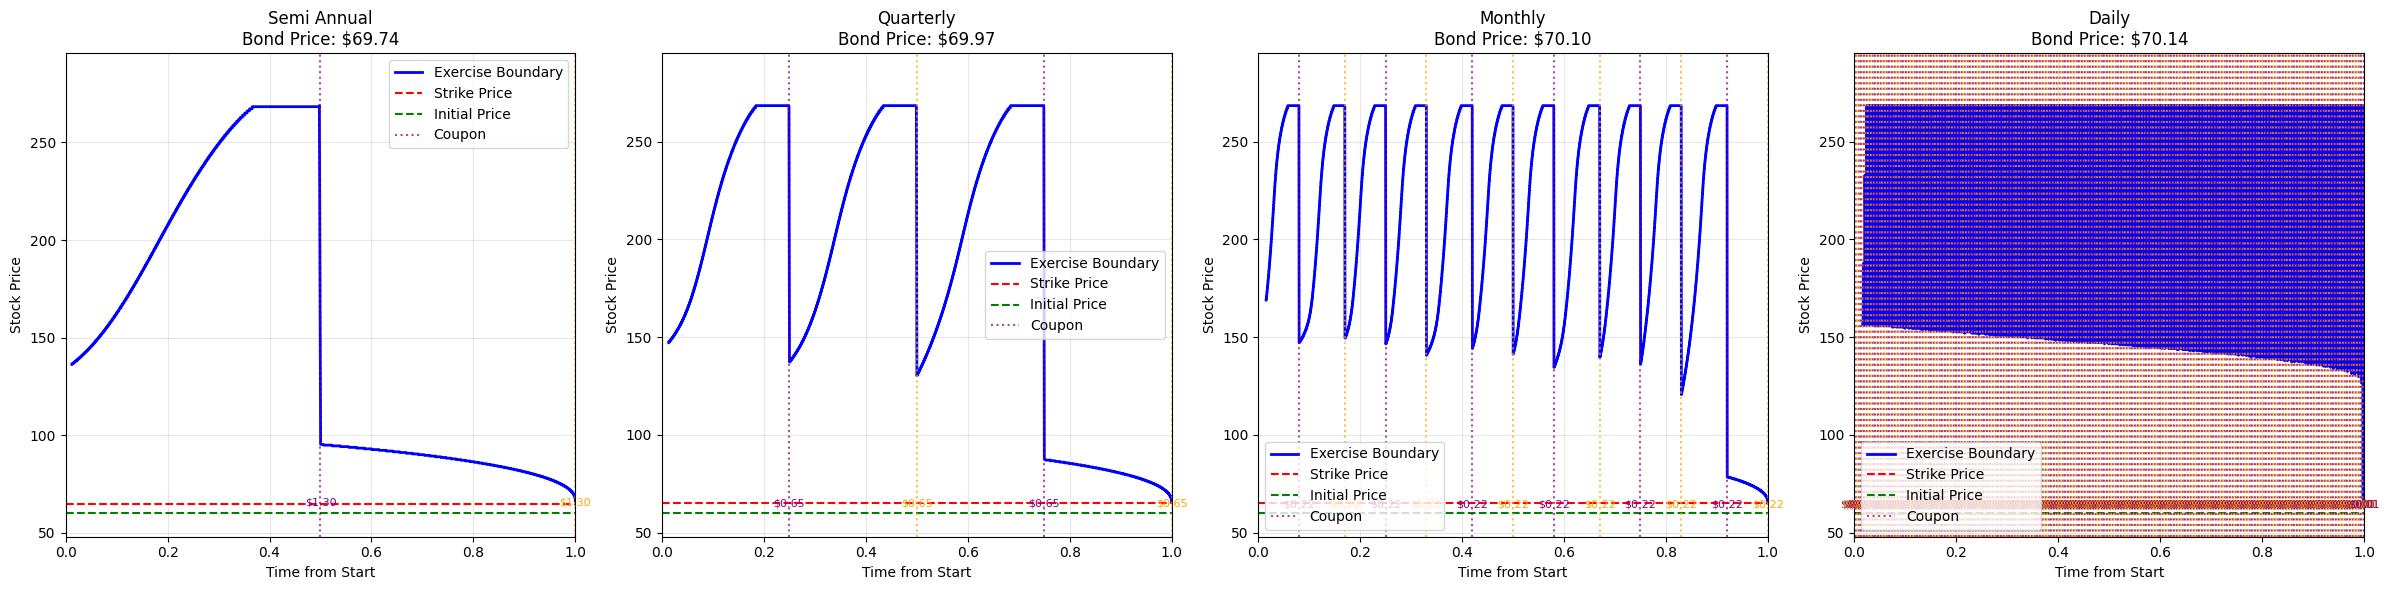


SUMMARY RESULTS - TRINOMIAL TREE
Coupon Structure Conversion Option Convertible Price  Coupon Payments Total Coupons Runtime (s)
     Semi Annual           $5.4088          $69.7432                2         $2.60        1.08
       Quarterly           $5.6156          $69.9657                4         $2.60        0.99
         Monthly           $5.7351          $70.0962               12         $2.60        0.98
           Daily           $5.7815          $70.1390              365         $2.59        0.94

BOUNDARY STATISTICS - TRINOMIAL TREE

Semi Annual:
  Min boundary: $66.30
  Max boundary: $268.90
  Avg boundary: $152.52
  Points: 16147/16385

Quarterly:
  Min boundary: $65.65
  Max boundary: $268.35
  Avg boundary: $185.86
  Points: 16128/16385

Monthly:
  Min boundary: $65.22
  Max boundary: $268.35
  Avg boundary: $211.07
  Points: 16108/16385

Daily:
  Min boundary: $65.01
  Max boundary: $268.35
  Avg boundary: $222.94
  Points: 16061/16385

KEY OBSERVATIONS - TRINOMIAL TR

In [11]:
def trinomial_tree_convertible_continuous(S0=60.0, K=65.0, T=1.0, sigma=0.3, r=0.05, q=0.02, 
                                        n=200, coupon_configs=None):
    """
    Trinomial tree for Convertible Bond with CONTINUOUS dividends and DISCRETE coupons
    Fixed logic: Coupon applied BEFORE exercise decision, time correctly tracked
    """
    print("=== Trinomial Tree - Convertible Bond with Continuous Dividends ===")
    print(f"Parameters: S0={S0}, K={K}, r={r}, sigma={sigma}, q={q}, T={T}")
    print(f"Time steps: {n}")
    
    if coupon_configs is None:
        coupon_configs = {
            'semi_annual': {'times': [0.5, 1.0], 'amounts': [1.3, 1.3]},
            'quarterly': {'times': [0.25, 0.5, 0.75, 1.0], 'amounts': [0.65, 0.65, 0.65, 0.65]},
            'monthly': {'times': [round(i/12, 2) for i in range(1, 13)], 'amounts': [0.2167] * 12},
            'daily': {'times': [round(i/365, 4) for i in range(1, 366)], 'amounts': [0.0071] * 365}
        }
    
    lambda_ = math.sqrt(3)
    dt = T / n
    h = lambda_ * sigma * math.sqrt(dt)
    
    # Adjust probabilities for continuous dividends: r - q
    mu_drift = (r - q - 0.5 * sigma**2) * math.sqrt(dt) / (2 * lambda_ * sigma)
    qu = 0.5 / (lambda_**2) + mu_drift
    qm = 1 - 1 / (lambda_**2)
    qd = 0.5 / (lambda_**2) - mu_drift
    
    discount = math.exp(-r * dt)
    offset = n
    
    def build_stock_grid(S0, n, h):
        """Build stock price grid"""
        Ss = np.zeros(2 * n + 1)
        for j in range(0, 2 * n + 1):
            Ss[j] = S0 * np.exp((n - j) * h)
        return Ss
    
    results = {}
    all_boundaries = {}
    
    for coupon_name, coupon_config in coupon_configs.items():
        print(f"\n--- {coupon_name.upper().replace('_', ' ')} ---")
        coupon_times = coupon_config['times']
        coupon_amounts = coupon_config['amounts']
        
        # Convert coupon times to step indices (forward steps from 0)
        coupon_steps = {}
        for t, amount in zip(coupon_times, coupon_amounts):
            i_step = int(round(n * (t / T)))
            i_step = max(1, min(n, i_step))
            if i_step not in coupon_steps:
                coupon_steps[i_step] = 0
            coupon_steps[i_step] += amount
        
        print(f"Coupon payments: {len(coupon_times)} at times {coupon_times}")
        print(f"Coupon amounts: {coupon_amounts}")
        print(f"Step indices (forward): {sorted(coupon_steps.keys())}")
        
        start_time = time.perf_counter()
        
        # Build stock grid
        Ss = build_stock_grid(S0, n, h)
        Ss = np.clip(Ss, 0, S0 * np.exp(5 * sigma * np.sqrt(T)))  # Cap grid
        
        # Initialize value matrix
        V = np.zeros((n + 1, 2 * n + 1))
        
        # Terminal condition: max(S, K + final_coupon) at maturity
        final_coupon = coupon_steps.get(n, 0)
        V[n, :] = np.maximum(Ss, K + final_coupon)
        
        # Store exercise boundaries (time from 0 to T)
        boundaries = []
        
        # Backward induction: from i=n-1 down to i=0 (i is forward step)
        for i in range(n - 1, -1, -1):
            start_idx = offset - i
            end_idx = offset + i + 1
            
            # Current time from start
            current_time = i * dt
            
            # Expected continuation value
            continuation = discount * (
                qu * V[i + 1, start_idx - 1 : end_idx - 1] +  # up (lower j)
                qm * V[i + 1, start_idx : end_idx] +
                qd * V[i + 1, start_idx + 1 : end_idx + 1]    # down (higher j)
            )
            
            # Add coupon if paid at this time step (before decision)
            coupon = coupon_steps.get(i, 0)
            continuation += coupon
            
            # Current stock prices
            S_curr = Ss[start_idx:end_idx]
            
            # American conversion: max(S, continuation)
            conversion_value = S_curr
            V[i, start_idx:end_idx] = np.maximum(conversion_value, continuation)
            
            # Find exercise boundary (lowest S where exercise optimal)
            convert_optimal = conversion_value >= continuation
            reasonable_convert = convert_optimal & (S_curr > K * 0.5) & (S_curr < S0 * 5.0)
            
            if np.any(reasonable_convert):
                boundary_price = np.min(S_curr[reasonable_convert])
            else:
                boundary_price = np.nan
            
            boundaries.append((current_time, boundary_price))
        
        # Reverse boundaries to from T to 0? No, since loop from n-1 to 0, append is from near maturity to 0
        boundaries = list(reversed(boundaries))
        boundaries.append((T, max(K, K + final_coupon)))  # at maturity
        
        # Price at t=0
        price = V[0, offset]
        duration = time.perf_counter() - start_time
        
        # Components
        B = K * math.exp(-r * T)
        pv_coupons = sum(amount * math.exp(-r * t) for amount, t in zip(coupon_amounts, coupon_times))
        straight_bond = B + pv_coupons
        conversion_option = price - straight_bond
        
        # Store
        results[coupon_name] = {
            'convertible_price': price,
            'straight_bond': straight_bond,
            'conversion_option': conversion_option,
            'runtime': duration,
            'boundaries': boundaries
        }
        
        all_boundaries[coupon_name] = boundaries
        
        print(f"Conversion option value: {conversion_option:.6f}")
        print(f"Convertible bond price: {price:.6f}")
        print(f"Runtime: {duration:.2f}s")
    
    # Visualization...
    print("\n" + "="*50)
    print("EXERCISE BOUNDARY VISUALIZATION")
    print("="*50)
    
    fig, axes = plt.subplots(1, 4, figsize=(24, 6))
    
    for i, (coupon_name, boundaries) in enumerate(all_boundaries.items()):
        if boundaries:
            t_b, S_b = zip(*boundaries)
            valid_mask = ~np.isnan(S_b)
            t_valid = np.array(t_b)[valid_mask]
            S_valid = np.array(S_b)[valid_mask]
            
            axes[i].plot(t_valid, S_valid, 'b-', linewidth=2, label='Exercise Boundary')
            axes[i].axhline(y=K, color='r', linestyle='--', label='Strike Price')
            axes[i].axhline(y=S0, color='g', linestyle='--', label='Initial Price')
            
            coupon_times = coupon_configs[coupon_name]['times']
            coupon_amounts = coupon_configs[coupon_name]['amounts']
            
            for j, (ct, amount) in enumerate(zip(coupon_times, coupon_amounts)):
                color = 'purple' if j % 2 == 0 else 'orange'
                axes[i].axvline(x=ct, color=color, linestyle=':', alpha=0.7, label='Coupon' if j==0 else None)
                y_pos = min(S_valid) * 0.95 if len(S_valid)>0 else S0 * 0.8
                axes[i].text(ct, y_pos, f'${amount:.2f}', ha='center', va='bottom', fontsize=8, color=color)
            
            axes[i].set_xlabel('Time from Start')
            axes[i].set_ylabel('Stock Price')
            title = f'{coupon_name.replace("_", " ").title()}\nBond Price: ${results[coupon_name]["convertible_price"]:.2f}'
            axes[i].set_title(title)
            axes[i].legend()
            axes[i].grid(True, alpha=0.3)
            axes[i].set_ylim(S0 * 0.8, max(max(S_valid)*1.1 if len(S_valid)>0 else K*1.5, S0*1.5))
            axes[i].set_xlim(0, T)
    
    plt.tight_layout()
    plt.show()
    
    # Summary
    print("\n" + "="*80)
    print("SUMMARY RESULTS - TRINOMIAL TREE")
    print("="*80)
    
    summary_data = []
    for coupon_name, result in results.items():
        summary_data.append({
            'Coupon Structure': coupon_name.replace('_', ' ').title(),
            'Conversion Option': f"${result['conversion_option']:.4f}",
            'Convertible Price': f"${result['convertible_price']:.4f}",
            'Coupon Payments': len(coupon_configs[coupon_name]['times']),
            'Total Coupons': f"${sum(coupon_configs[coupon_name]['amounts']):.2f}",
            'Runtime (s)': f"{result['runtime']:.2f}"
        })
    
    summary_df = pd.DataFrame(summary_data)
    print(summary_df.to_string(index=False))
    
    # Boundary stats
    print("\n" + "="*80)
    print("BOUNDARY STATISTICS - TRINOMIAL TREE")
    print("="*80)
    
    for coupon_name, boundaries in all_boundaries.items():
        if boundaries:
            t_b, S_b = zip(*boundaries)
            S_valid = np.array([s for s in S_b if not np.isnan(s)])
            
            if len(S_valid) > 0:
                print(f"\n{coupon_name.replace('_', ' ').title()}:")
                print(f"  Min boundary: ${np.min(S_valid):.2f}")
                print(f"  Max boundary: ${np.max(S_valid):.2f}")
                print(f"  Avg boundary: ${np.mean(S_valid):.2f}")
                print(f"  Points: {len(S_valid)}/{len(boundaries)}")
    
    print("\n" + "="*80)
    print("KEY OBSERVATIONS - TRINOMIAL TREE")
    print("="*80)
    print(f"1. Continuous dividends (q={q}) via adjusted drift")
    print("2. Discrete coupons added before exercise decision")
    print("3. Terminal: max(S, K + final_coupon)")
    print("4. Conversion option = convertible - straight bond")
    print(f"5. Time steps (n={n}) for smoother boundaries")
    
    return results, all_boundaries

# Run the trinomial tree with continuous dividends
if __name__ == "__main__":
    # Parameters (matching your request)
    S0 = 60.0
    K = 65.0
    r = 0.05  # Risk-free rate
    sigma = 0.3
    T = 1.0
    q = 0.02  # Continuous dividend yield
    n = 16384  # Time steps
    
    # Coupon configurations (same as Monte Carlo)
    coupon_configs = {
        'semi_annual': {'times': [0.5, 1.0], 'amounts': [1.3, 1.3]},
        'quarterly': {'times': [0.25, 0.5, 0.75, 1.0], 'amounts': [0.65, 0.65, 0.65, 0.65]},
        'monthly': {'times': [round(i/12, 2) for i in range(1, 13)], 'amounts': [0.2167] * 12},
        'daily': {'times': [round(i/365, 4) for i in range(1, 366)], 'amounts': [0.0071] * 365}
    }
    
    # Run trinomial tree
    results, boundaries = trinomial_tree_convertible_continuous(
        S0=S0, K=K, T=T, sigma=sigma, r=r, q=q, n=n, coupon_configs=coupon_configs
    )